# **🚗ML Project:Used Car Price Prediction**

**Dataset:** used_cars_data.csv

**Language:** Python

**1️⃣ Objective**
To build a Machine Learning model that predicts the selling price of a used car based on its features.

**2️⃣ Target Column Selection**

**🎯 Target Column: Price**

Why Price?

* It is the value we want to predict
* It is numerical
* This makes the problem a Regression Problem
  
   





In [ ]:
#1-import required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression


In [ ]:
# 2- Load Dataset
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving used_cars_data.csv to used_cars_data (1).csv


,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [ ]:
df.head(15)

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
5,5,Hyundai EON LPG Era Plus Option,Hyderabad,2012,75000,LPG,Manual,First,21.1 km/kg,814 CC,55.2 bhp,5.0,NaN,2.35
6,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50
7,7,Toyota Innova Crysta 2.8 GX AT 8S,Mumbai,2016,36000,Diesel,Automatic,First,11.36 kmpl,2755 CC,171.5 bhp,8.0,21 Lakh,17.50
8,8,Volkswagen Vento Diesel Comfortline,Pune,2013,64430,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.0,NaN,5.20
9,9,Tata Indica Vista Quadrajet LS,Chennai,2012,65932,Diesel,Manual,Second,22.3 kmpl,1248 CC,74 bhp,5.0,NaN,1.95


In [ ]:
#To see the size of the dataset
df.shape

(7253, 13)

In [ ]:
#To check the values in datasets
df.isnull().sum()

,0
S.No.,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,0
Engine,0


In [ ]:
#Gives a statical summary of numerical columns in a dtaframe
df.describe()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
count,7253.000000,7253.000000,7253.000000,7253.000000,7.253000e+03,7253.000000,7253.000000,7253.000000,7253.000000,7253.000000,7253.000000,7253.000000,7253.000000
mean,3626.000000,998.547773,5.622363,2013.365366,5.869906e+04,2.370330,0.717496,0.375982,18.141266,1613.912450,111.829889,5.277678,8.826235
std,2093.905084,577.521935,2.969663,3.254421,8.442772e+04,1.504603,0.450248,0.815908,4.561607,594.328359,53.177958,0.809039,10.293313
min,0.000000,0.000000,0.000000,1996.000000,1.710000e+02,0.000000,0.000000,0.000000,0.000000,72.000000,34.200000,0.000000,0.440000
25%,1813.000000,514.000000,3.000000,2011.000000,3.400000e+04,1.000000,0.000000,0.000000,15.170000,1197.000000,74.000000,5.000000,3.850000
50%,3626.000000,1017.000000,6.000000,2014.000000,5.341600e+04,1.000000,1.000000,0.000000,18.160000,1462.000000,91.100000,5.000000,5.640000
75%,5439.000000,1434.000000,8.000000,2016.000000,7.300000e+04,4.000000,1.000000,0.000000,21.100000,1968.000000,138.030000,5.000000,8.400000
max,7252.000000,2040.000000,10.000000,2019.000000,6.500000e+06,4.000000,1.000000,3.000000,33.540000,5998.000000,616.000000,10.000000,160.000000


In [ ]:
#it used to detect duplicate rows in columns
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
7248,False
7249,False
7250,False
7251,False


In [ ]:
#Handle missing values
df["Seats"].fillna(df["Seats"].median(), inplace=True)
df["Mileage"].fillna(df["Mileage"].mode()[0], inplace=True)
df["Engine"].fillna(df["Engine"].mode()[0], inplace=True)
df["Power"].fillna(df["Power"].mode()[0], inplace=True)
df["Price"].fillna(df["Price"].median(), inplace=True)


import warnings
warnings.filterwarnings("ignore")

In [ ]:
df.isnull().sum()

,0
S.No.,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,0
Engine,0


In [ ]:
df.drop('New_Price',axis=1,inplace=True)

In [ ]:
df.isnull().sum()

,0
S.No.,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,0
Engine,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7253 non-null   object 
 9   Engine             7253 non-null   object 
 10  Power              7253 non-null   object 
 11  Seats              7253 non-null   float64
 12  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(8)
memory usage: 736.8+ KB


In [ ]:
# Ensure columns are string type before applying string operations
df["Mileage"] = df["Mileage"].astype(str)
df["Engine"] = df["Engine"].astype(str)
df["Power"] = df["Power"].astype(str)

df["Mileage"] = df["Mileage"].str.replace(" kmpl","", regex=False).str.replace(" km/kg","", regex=False)
df["Engine"] = df["Engine"].str.replace(" CC","", regex=False)
df["Power"] = df["Power"].str.replace(" bhp","", regex=False)

# Convert to float, coercing any non-numeric values (like 'null' strings) to NaN
df[["Mileage","Engine","Power"]] = df[["Mileage","Engine","Power"]].apply(pd.to_numeric, errors='coerce')

In [ ]:
#Encoding categorical columns
le = LabelEncoder()

categorical_cols = ["Location", "Fuel_Type", "Transmission", "Owner_Type", "Name"]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
#Feature & Target Separation
x= df.drop("Price", axis=1)
y = df["Price"]

In [ ]:
#Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [ ]:
#Model Building(Linear Regression)
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [ ]:
#Preduction
y_pred_lr = lr.predict(x_test)

In [ ]:
#Evaluation
print("Linear Regression Performance")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Performance
MAE: 3.7780475299185756
MSE: 53.247098795063174
RMSE: 7.29706096966876
R2 Score: 0.4624473752119792


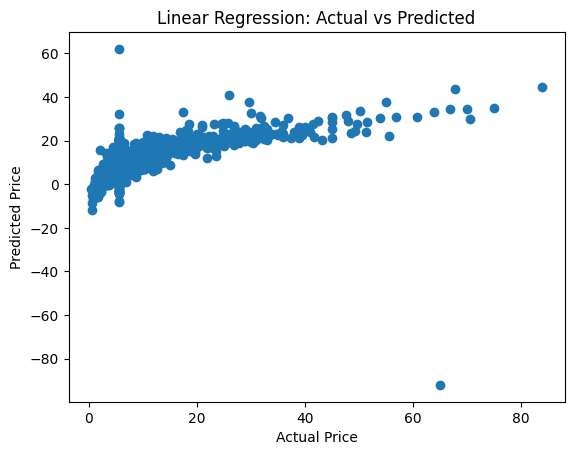

In [ ]:
#Graph: Actual vs Predicted
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

In [ ]:
#Polynomial Regresstion
#Train test split(Polynomial Data)
poly_features = PolynomialFeatures(degree=2)
x_poly = poly_features.fit_transform(x)

x_train_p, x_test_p, y_train_p, y_test_p = train_test_split(
    x_poly, y, test_size=0.2, random_state=42)

In [ ]:
#Model Trainig
lr_poly = LinearRegression()
lr_poly.fit(x_train_p, y_train_p)

LinearRegression()

In [ ]:
#Predicion
y_pred_poly = lr_poly.predict(x_test_p)

In [ ]:
#Evaluation
print("Polynomial Regression Performance")
print("MAE:", mean_absolute_error(y_test_p, y_pred_poly))
print("MSE:", mean_squared_error(y_test_p, y_pred_poly))
print("RMSE:", np.sqrt(mean_squared_error(y_test_p, y_pred_poly)))
print("R2 Score:", r2_score(y_test_p, y_pred_poly))

Polynomial Regression Performance
MAE: 3.7174978175340216
MSE: 1725.7971791733971
RMSE: 41.54271511556987
R2 Score: -16.422673244357764


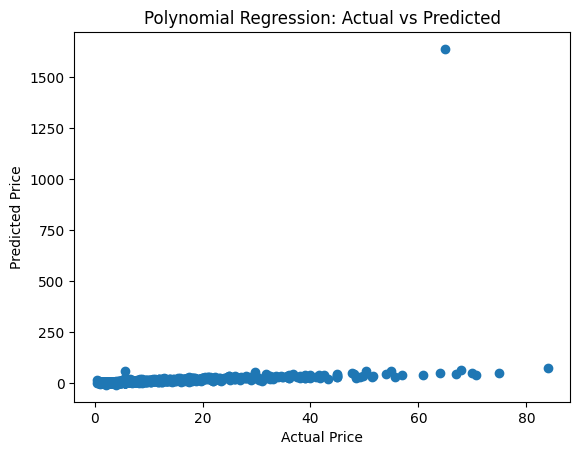

In [ ]:
#Graph: Actual vs Predicted
plt.scatter(y_test_p, y_pred_poly)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Polynomial Regression: Actual vs Predicted")
plt.show()

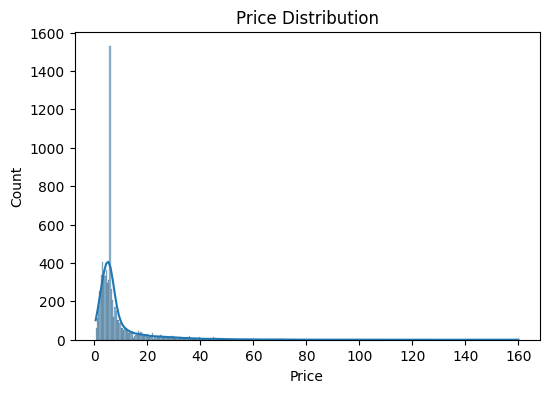

In [ ]:
#Data Visualization(Graphs)
#Price Distibution
plt.figure(figsize=(6,4))
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

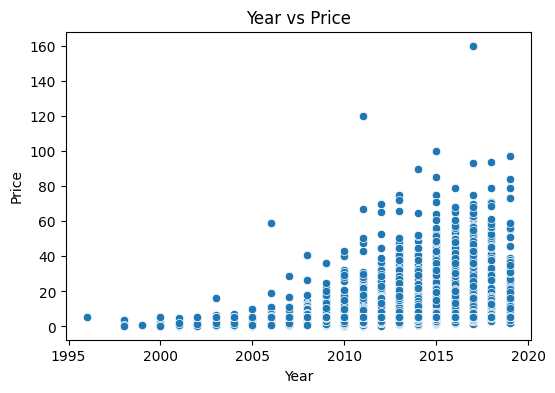

In [ ]:
#Year vs Price
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Year"], y=df["Price"])
plt.title("Year vs Price")
plt.show()

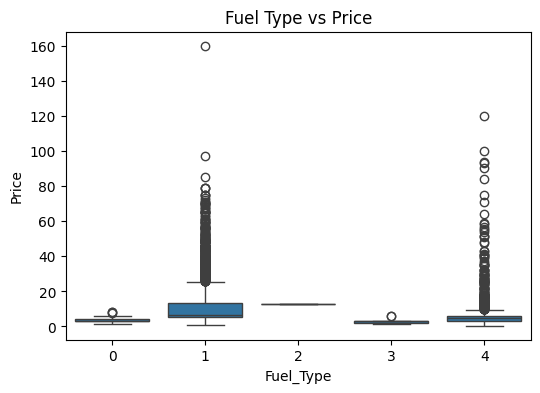

In [ ]:
#Fuel Type vs price
plt.figure(figsize=(6,4))
sns.boxplot(x="Fuel_Type", y="Price", data=df)
plt.title("Fuel Type vs Price")
plt.show()

In [ ]:
#Model bulding (Random Forest Regression)
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(x_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
#Model Prediction
y_pred = model.predict(x_test)

In [ ]:
#Model Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print(f"R2 Score:,{r2_score(y_test, y_pred)*100:.2f}%")

MAE: 1.2165460027567196
MSE: 7.287654155559955
RMSE: 2.699565549409748
R2 Score:,92.64%


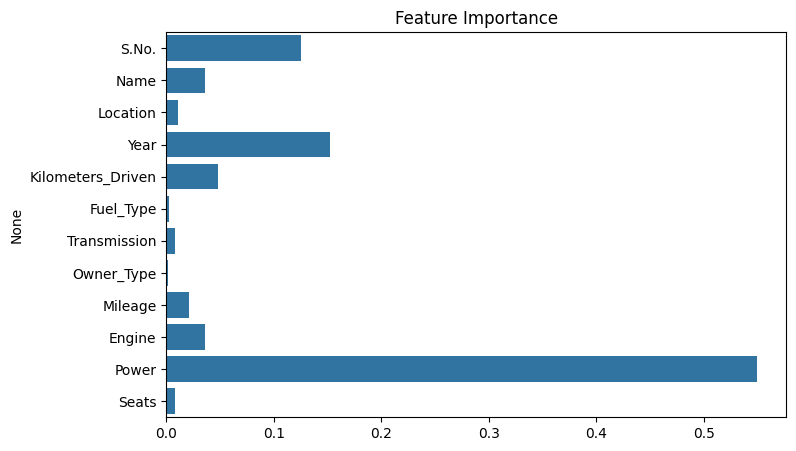

In [ ]:
#Feature importance
importances = model.feature_importances_
features = x.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

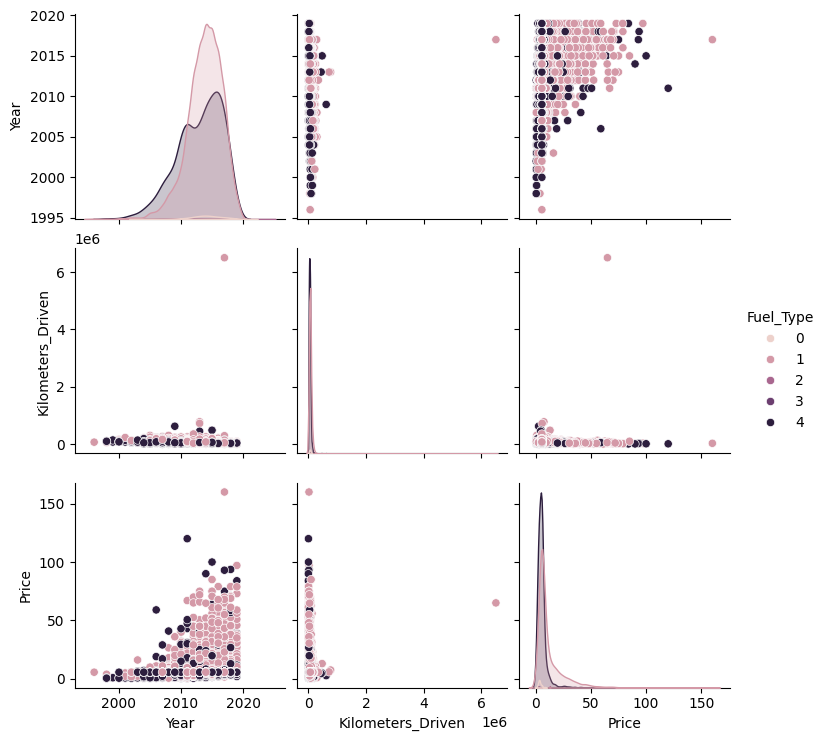

In [ ]:
#pair plot(Relationship between importance features)
sns.pairplot(
    df[['Year', 'Kilometers_Driven', 'Price', 'Fuel_Type']],
    hue='Fuel_Type'
)

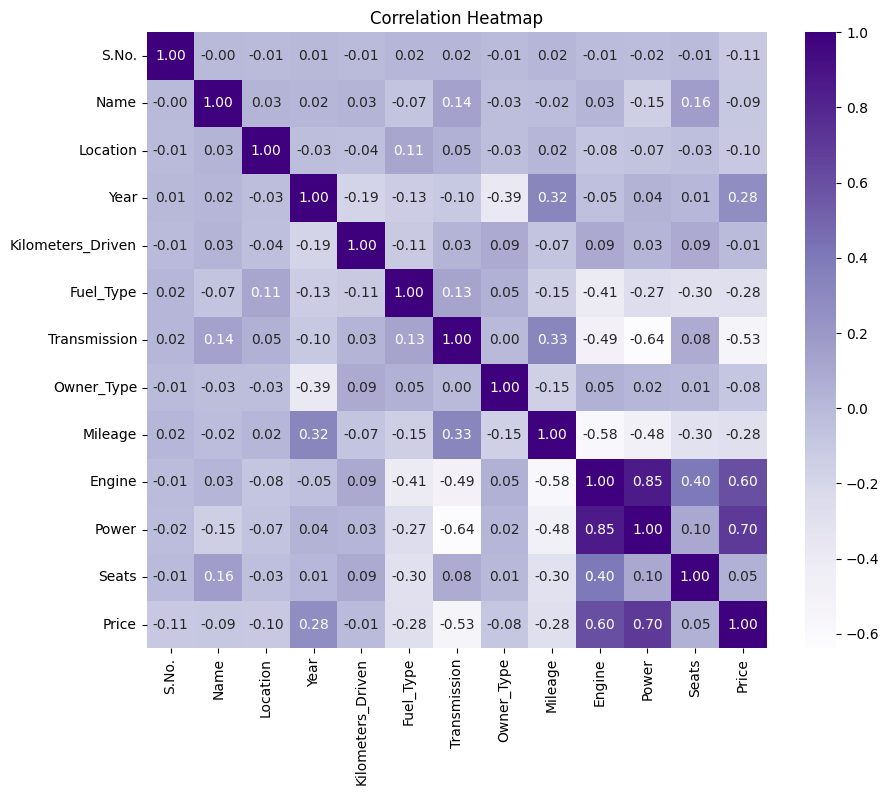

In [ ]:
#Correlation heatmap
h_corr=df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(h_corr,annot=True,cmap='Purples',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


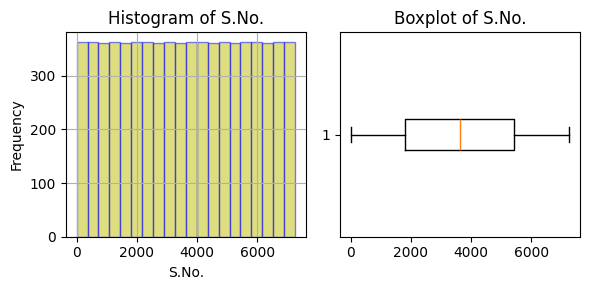

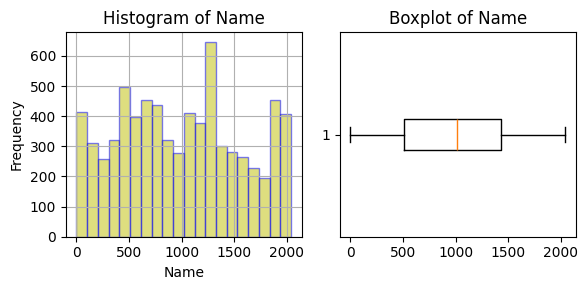

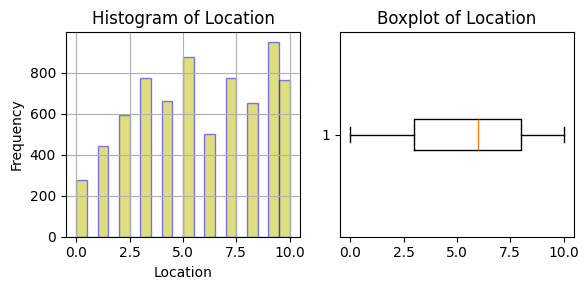

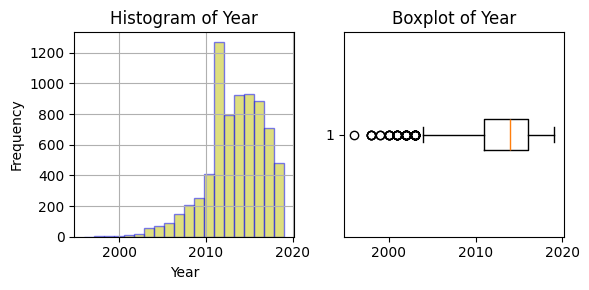

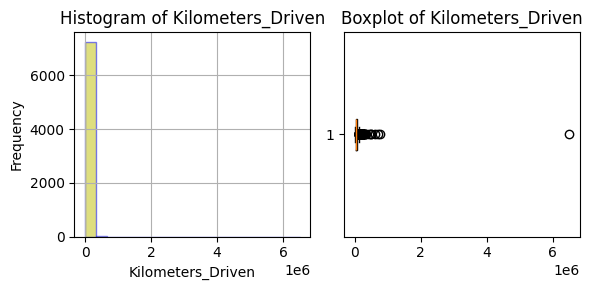

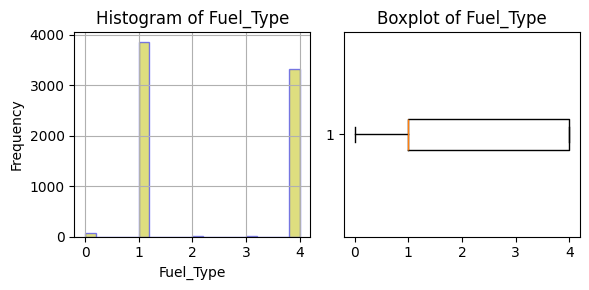

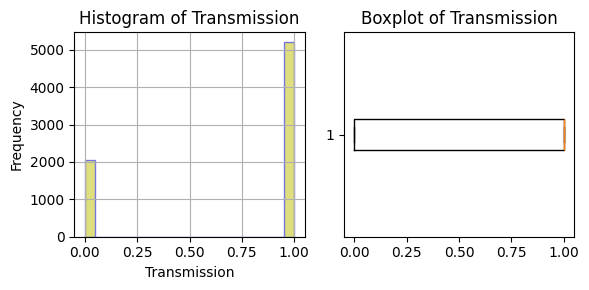

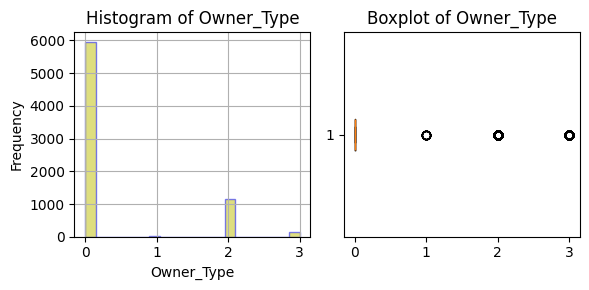

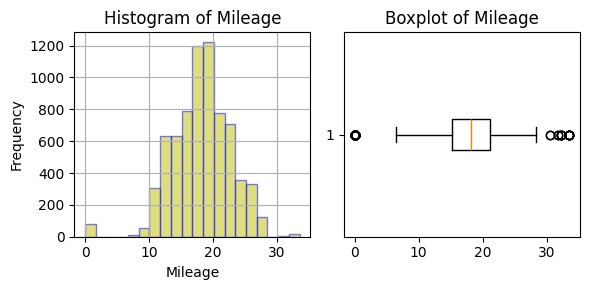

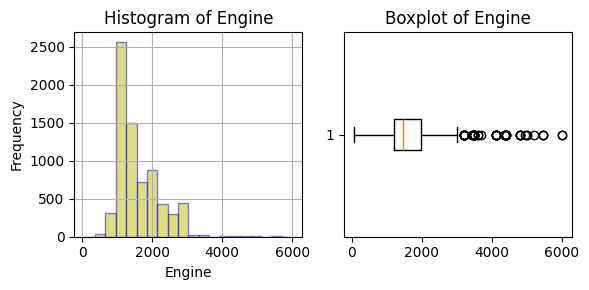

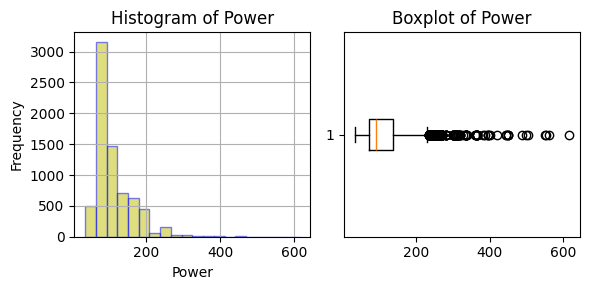

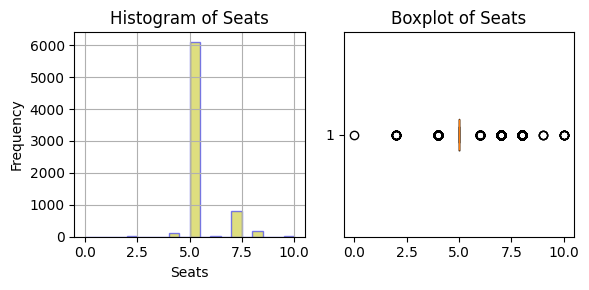

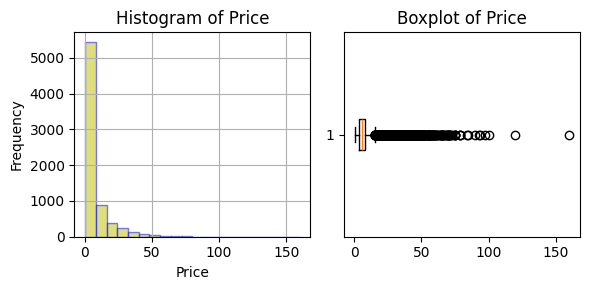

In [ ]:
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for i in numeric_cols:
    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    df[i].hist(bins=20, alpha=0.5, color='y', edgecolor='blue')
    plt.title(f'Histogram of {i}')
    plt.xlabel(i)
    plt.ylabel('Frequency')

    plt.subplot(1,2,2)
    plt.boxplot(df[i], vert=False)
    plt.title(f'Boxplot of {i}')

    plt.tight_layout()
    plt.show()

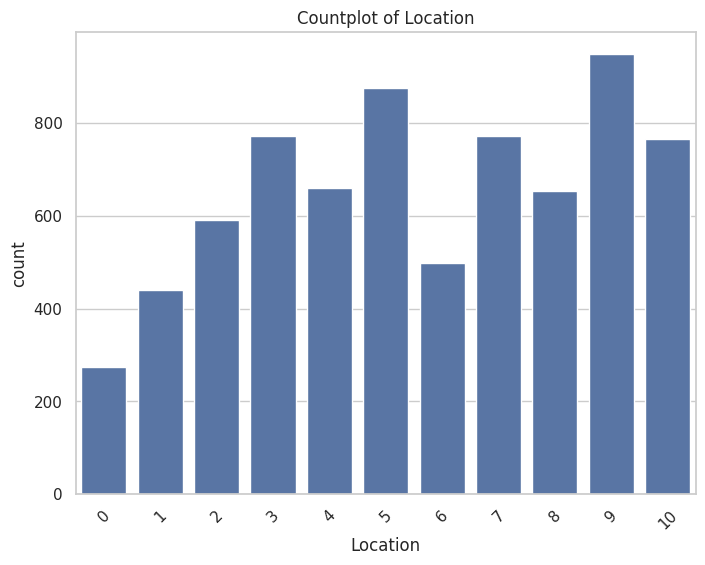

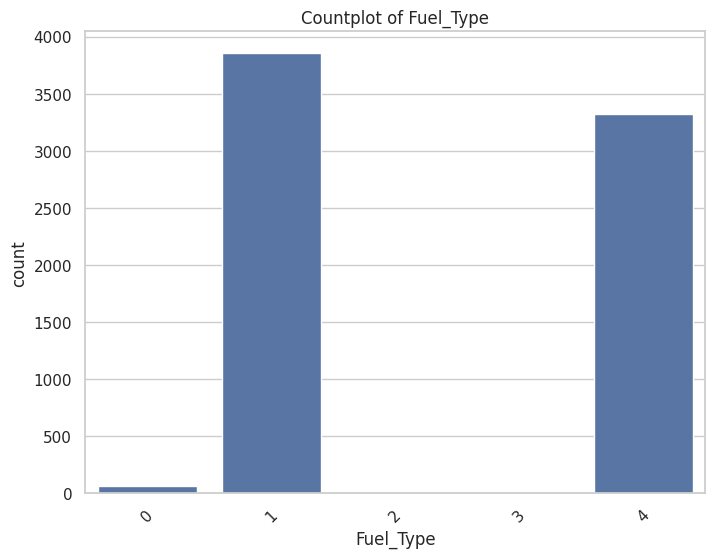

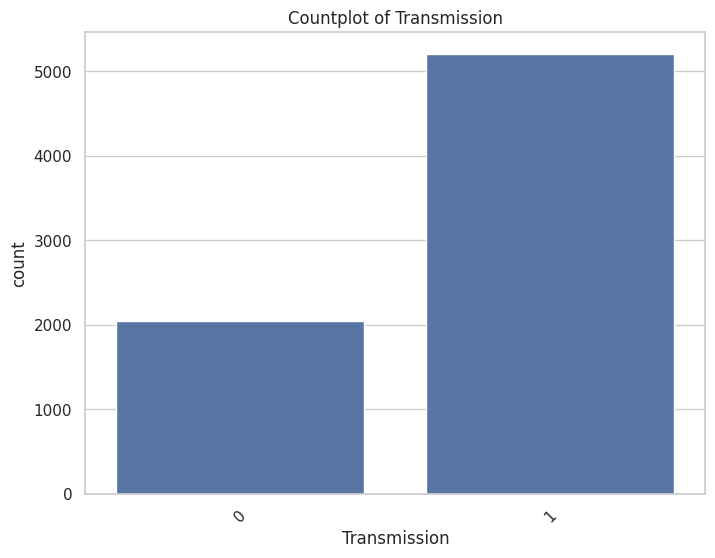

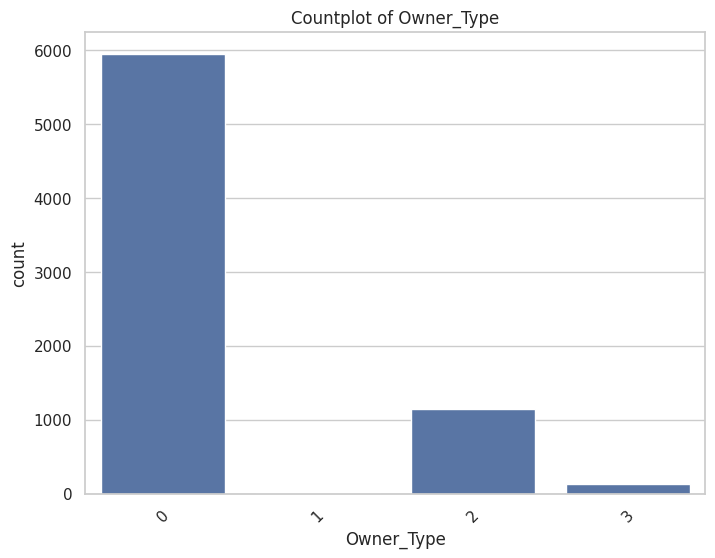

In [ ]:
#set the style of the graph
sns.set(style='whitegrid')

# Define the categorical columns
categorical_cols = ["Location", "Fuel_Type", "Transmission", "Owner_Type"]
cat = df[categorical_cols]

#we will get the countplots of all the categorical features in the df
for i in cat.columns:
    plt.figure(figsize=(8,6))
    sns.countplot(data=cat, x=i)
    plt.title(f'Countplot of {i}')
    plt.xticks(rotation=45)
    plt.show()

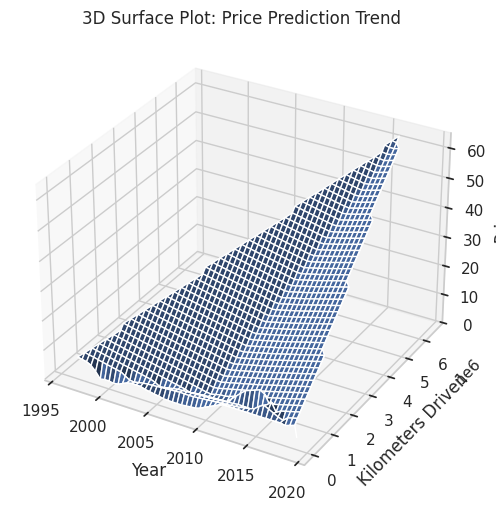

In [ ]:
#3-D sourface plot
import numpy as np
from scipy.interpolate import griddata

x = df["Year"]
y = df["Kilometers_Driven"]
z = df["Price"]

xi = np.linspace(x.min(), x.max(), 50)
yi = np.linspace(y.min(), y.max(), 50)
xi, yi = np.meshgrid(xi, yi)

zi = griddata((x, y), z, (xi, yi), method='linear')

fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(xi, yi, zi)

ax.set_xlabel("Year")
ax.set_ylabel("Kilometers Driven")
ax.set_zlabel("Price")
ax.set_title("3D Surface Plot: Price Prediction Trend")

plt.show()

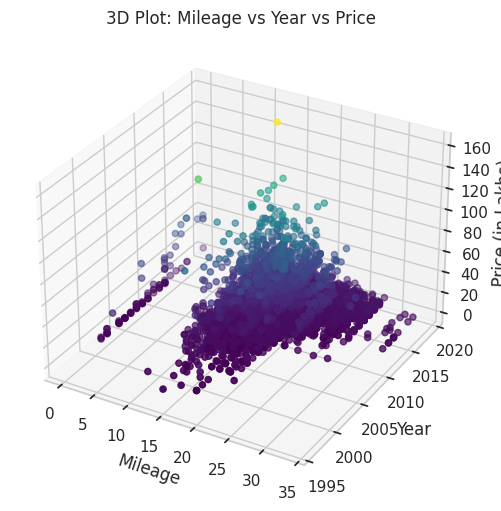

In [ ]:
#3_D Scatter plot
#mileage vs year vs price
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df["Mileage"],
    df["Year"],
    df["Price"],
    c=df["Price"],
    cmap="viridis"
)

ax.set_xlabel("Mileage")
ax.set_ylabel("Year")
ax.set_zlabel("Price (in Lakhs)")
ax.set_title("3D Plot: Mileage vs Year vs Price")

plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predict on test data
y_pred = model.predict(x_test)

# Accuracy using R2 Score
r2 = r2_score(y_test, y_pred)

# Error metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Model Performance:")
print("R2 Score (Accuracy):", r2)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Model Performance:
R2 Score (Accuracy): 0.9264279611750078
Mean Absolute Error (MAE): 1.2165460027567196
Mean Squared Error (MSE): 7.287654155559955
Root Mean Squared Error (RMSE): 2.699565549409748


## **Conclusion:**

* The Price of used cars can be predicted effectively using ML
* Random Forest Regressor provides high accuracy
* Important features include Year, Power, Engine, Kilometers Driven
